# PhishGuard Live — Exploratory Data Analysis

Dataset built from real, live-collected data:
- **Phishing domains** — OpenPhish feed (updated ~every 6h)
- **Legit domains** — random sample from the Tranco top-1M list

Each domain was converted into numeric features (`src/features/extractor.py`):
domain length, digit/hyphen counts, brand-name similarity (Levenshtein),
suspicious TLD flag, and phishing-keyword count.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/dataset.csv")
df.head()

,length,digits,hyphens,brand_sim,brand_sim_jaro,brand_sim_seqmatch,brand_sim_ngram,suspicious_tld,keywords,domain,label
0,10,0,0,0.4615,0.5873,0.4615,0.0,0,0,imgsaya.io,legit
1,11,0,0,0.2500,0.4476,0.2500,0.0,0,0,ciclick.net,legit
2,13,0,0,0.3333,0.5556,0.3333,0.0,0,0,issuewire.com,legit
3,21,0,0,0.3704,0.5556,0.2963,0.0,0,0,orbitgamingcentral.nl,legit
4,15,0,0,0.5714,0.7222,0.5714,0.0,0,0,socolive.studio,legit


## 1. Data overview

Checking dataset size, column types, and missing values before any analysis.

In [38]:
print(df.shape)
df.info()
df.isna().sum()
df.describe()

(2297, 11)
<class 'pandas.DataFrame'>
RangeIndex: 2297 entries, 0 to 2296
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   length              2297 non-null   int64  
 1   digits              2297 non-null   int64  
 2   hyphens             2297 non-null   int64  
 3   brand_sim           2297 non-null   float64
 4   brand_sim_jaro      2297 non-null   float64
 5   brand_sim_seqmatch  2297 non-null   float64
 6   brand_sim_ngram     2297 non-null   float64
 7   suspicious_tld      2297 non-null   int64  
 8   keywords            2297 non-null   int64  
 9   domain              2297 non-null   str    
 10  label               2297 non-null   str    
dtypes: float64(4), int64(5), str(2)
memory usage: 197.5 KB


,length,digits,hyphens,brand_sim,brand_sim_jaro,brand_sim_seqmatch,brand_sim_ngram,suspicious_tld,keywords
count,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000,2297.000000
mean,16.622116,0.683500,0.498912,0.354989,0.560749,0.340041,0.011247,0.014367,0.003918
std,8.915789,1.886005,1.143884,0.104055,0.099229,0.108632,0.042898,0.119022,0.062486
min,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,0.000000,0.000000,0.300000,0.521400,0.272700,0.000000,0.000000,0.000000
50%,14.000000,0.000000,0.000000,0.363600,0.566700,0.333300,0.000000,0.000000,0.000000
75%,18.000000,0.000000,0.000000,0.421100,0.611100,0.400000,0.000000,0.000000,0.000000
max,55.000000,13.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [39]:
df["label"].value_counts()

label
legit       2000
phishing     297
Name: count, dtype: int64

## 2. Class balance

Real-world phishing datasets are always imbalanced -- confirming that
here matters, since it determines which evaluation metrics make sense
later (accuracy would be misleading).

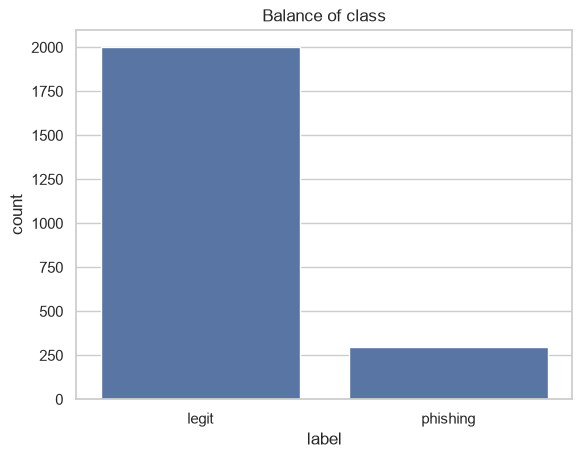

In [40]:
sns.countplot(data=df, x="label")
plt.title("Balance of class")
plt.show()

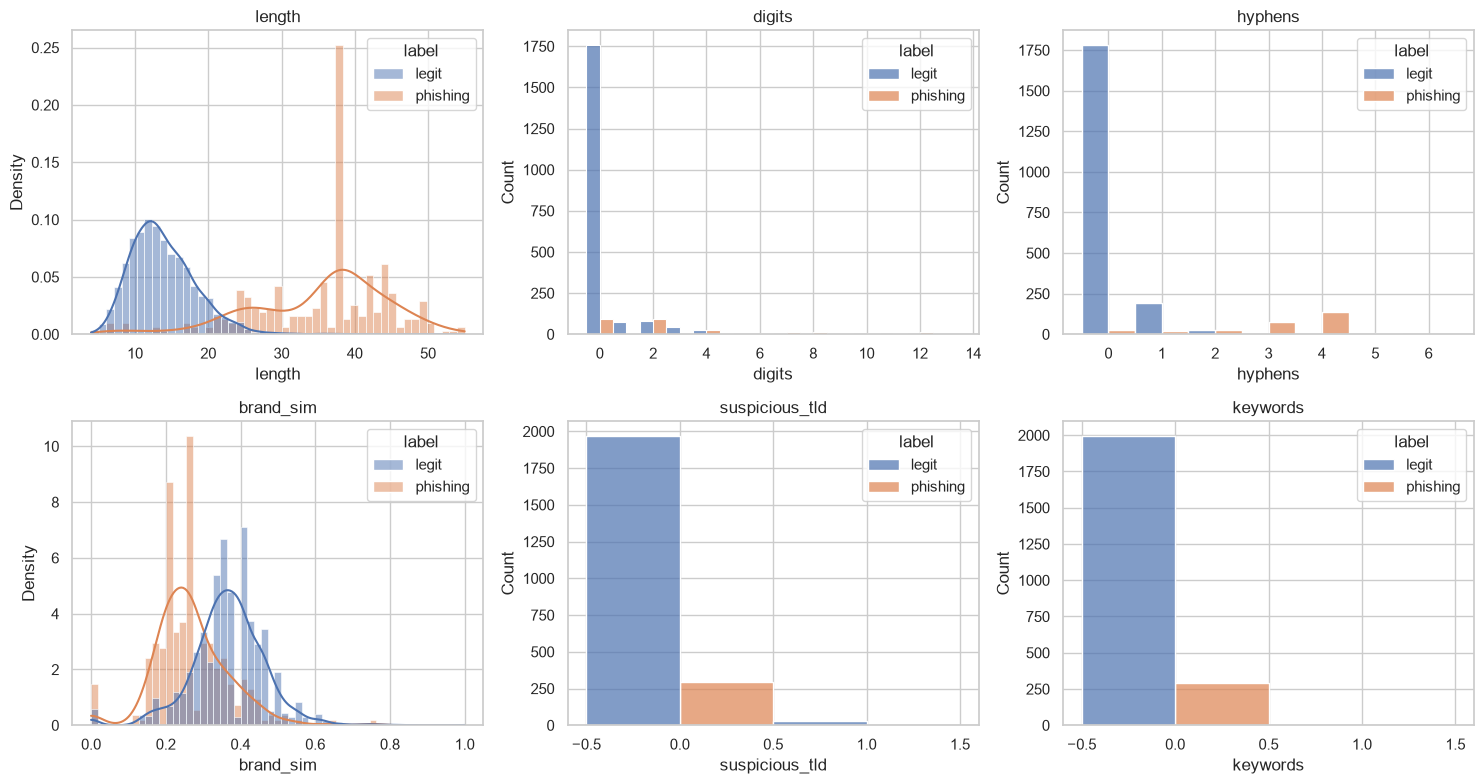

In [41]:
numeric_cols = ["length", "digits", "hyphens", "brand_sim", "suspicious_tld", "keywords"]
continuous_cols = ["length", "brand_sim"] 

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    if col in continuous_cols:
        sns.histplot(data=df, x=col, hue="label", kde=True, ax=axes[i],
                     stat="density", common_norm=False, alpha=0.5)
    else:
        sns.histplot(data=df, x=col, hue="label", kde=False, ax=axes[i],
                     discrete=True, multiple="dodge", alpha=0.7)
        
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [42]:
df.groupby("label")[numeric_cols].mean()

,length,digits,hyphens,brand_sim,suspicious_tld,keywords
label,,,,,,
legit,13.838500,0.286500,0.124500,0.367934,0.015500,0.002500
phishing,35.367003,3.356902,3.020202,0.267815,0.006734,0.013468


## Feature correlation heatmap

Checking how features relate to each other before moving to PCA and modeling.

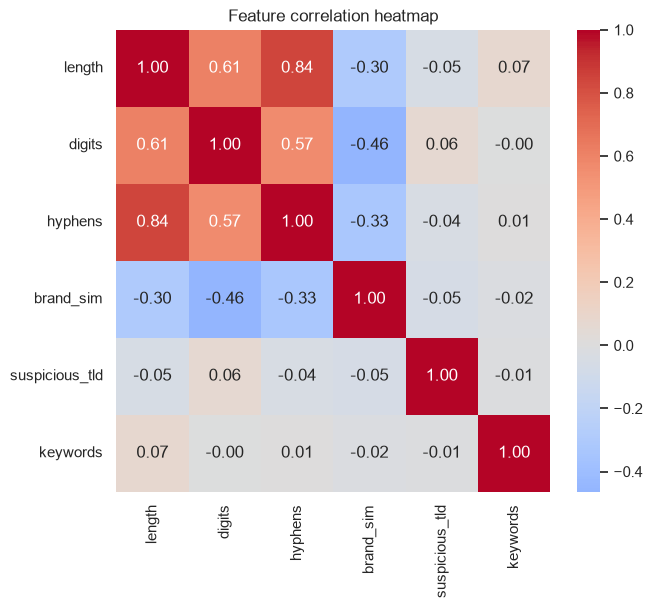

In [43]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.show()

## EDA summary

- Dataset is imbalanced: ~15% phishing, ~85% legit (real-world proportion).
- No missing values across all 2265 rows.
- `brand_sim` and `length` show clearly different distributions between
  classes and look like the strongest individual signals.
- Sparse features (`digits`, `hyphens`, `suspicious_tld`, `keywords`) have
  low frequency in both classes, but noticeably higher averages for
  phishing domains.
- Moderate correlation (0.6) between `length` and `hyphens` -- expected,
  since longer domains have more room for hyphens. Not high enough to be
  a multicollinearity concern.
- Next steps: PCA to visualize class separability in 2D, then train and
  compare several classification models.

## 6. PCA — dimensionality reduction

Projecting all 6 features into 2 dimensions to visually check whether
phishing and legit domains form separable clusters in feature space.
This is a sanity check before training any model.

In [44]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [45]:
X = df[numeric_cols].values
y = df["label"].values

In [46]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [47]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [48]:
print(pca.explained_variance_ratio_)

[0.43267154 0.17434714]


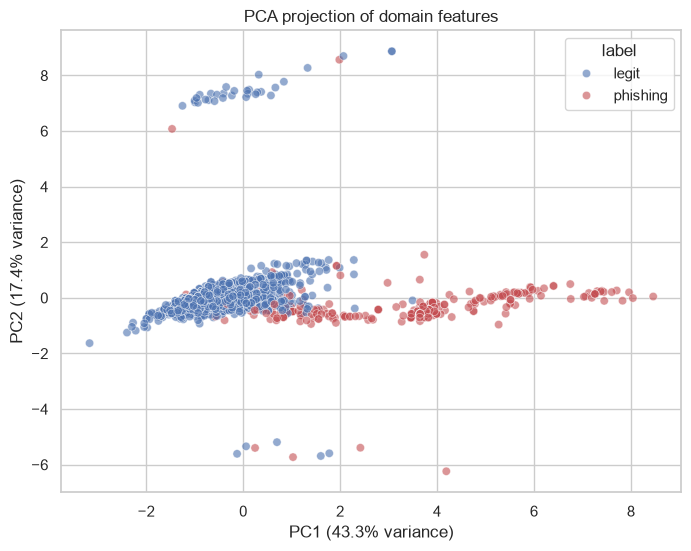

In [49]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["label"], alpha=0.6,
                 palette={"legit": "#4C72B0", "phishing": "#C44E52"})
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA projection of domain features")
plt.show()


## PCA conclusion

The two classes show partial separation: phishing domains tend to spread
toward higher PC1 values (longer names, higher brand similarity, more
keywords), while legit domains form a dense cluster near the origin.
There's significant overlap in the middle region, meaning the classes
aren't perfectly linearly separable in 2D -- this suggests non-linear
models (e.g. Random Forest) may outperform simpler linear ones later.

Note: PC1+PC2 only explain ~53.5% of total variance, so this 2D view
is a simplification -- the actual classifier will use all 6 features.

In [50]:
from sklearn.cluster import DBSCAN
import json
from pathlib import Path

In [51]:
eps_value = 1.2  
k = 12

dbscan = DBSCAN(eps=eps_value, min_samples=k)
cluster_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_outliers = list(cluster_labels).count(-1)
print(f"Clusters found: {n_clusters}")
print(f"Outlier points: {n_outliers} ({n_outliers/len(X):.1%} of all data)")

Clusters found: 3
Outlier points: 27 (1.2% of all data)


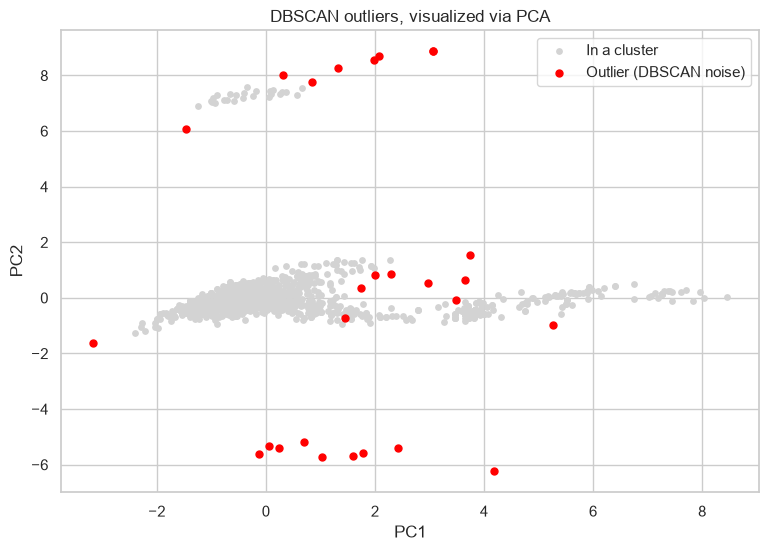

In [52]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))

# Normal points (part of a cluster) in gray, outliers in red
is_outlier = cluster_labels == -1
plt.scatter(X_pca[~is_outlier, 0], X_pca[~is_outlier, 1], c="lightgray", s=15, label="In a cluster")
plt.scatter(X_pca[is_outlier, 0], X_pca[is_outlier, 1], c="red", s=25, label="Outlier (DBSCAN noise)")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN outliers, visualized via PCA")
plt.legend()
plt.show()

In [53]:
FEATURE_COLUMNS = ["length", "digits", "hyphens", "brand_sim", "suspicious_tld", "keywords"]
outlier_df = df[is_outlier]
print(outlier_df[["domain", "label"] + FEATURE_COLUMNS])

                                                domain     label  length  \
48                            secure-hotel-booking.com     legit      24   
51                                topsecureservers.com     legit      20   
171                                      889993240.xyz     legit      13   
416                                     app.dbs-jp.top  phishing      14   
544                                         51m985.xyz     legit      10   
563                                    securemypass.io     legit      15   
597                      allegrolokalnie.pl-986234.lol  phishing      29   
638   leonardo-morales-law--p-c.p-j5xsl0oh.workers.dev  phishing      48   
673                www.site-qb19skear.godaddysites.com  phishing      35   
739                                      www.60720.xyz  phishing      13   
747                                           mx39.top     legit       8   
750                          xn--80actcpdfk0f.xn--p1ai     legit      25   
1164        

## Summary

DBSCAN found **3 dense clusters** and flagged **27 points (1.2%)** as outliers
— domains whose feature combination doesn't match any dominant pattern in
either class. At this small a share, they don't meaningfully affect training,
but they're a useful edge-case list: legit outliers are mostly domains that
*look* suspicious on paper (words like "secure", cheap TLDs like `.xyz`/`.top`/
`.buzz`) but are legitimate, while phishing outliers are cases hosted on
trusted platforms (`blogspot.com`, `pages.dev`, `workers.dev`, `replit.app`)
with unusually long, descriptive names — structurally different from the
typical short, brand-mimicking domain the model is tuned to catch. Kept in
the dataset rather than removed — they reflect real edge cases, not noise.